# 05 — Regression vs. ranking: which signal would you actually trade?

`ml-cross-sectional` ran the same 2020–2024 walk-forward on the same S&P 500 universe but predicted cross-sectional rank of the next-month return. Here I put the two signal families side by side and ask three things:

1. **Signal agreement.** Per-day Spearman correlation between the regressor's raw prediction and the ranker's cross-sectional score — do they even agree on which stocks to own?
2. **Top-20 overlap (Jaccard).** If I pick the 20 highest-scoring names from each model each month, how much do the baskets share?
3. **Drawdown behaviour.** In the 2022 macro-driven drawdown, which formulation held up better?

My prior going in: the ranker should dominate on drawdown and give a more stable top basket, because rank is invariant to the absolute-magnitude noise the regressor is forced to fit. Let's see if that holds.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

REG_PREDS  = Path("..").resolve() / "reports" / "predictions" / "oos_2020_2024.parquet"
RANK_PREDS = Path("..").resolve().parent / "ml-cross-sectional" / "reports" / "predictions" / "oos_2020_2024.parquet"
FEATURES   = sorted((Path("..").resolve() / "data" / "processed").glob("features_*_h21.parquet"))[-1]

print("Regressor preds :", REG_PREDS)
print("Ranker preds    :", RANK_PREDS, "· exists:", RANK_PREDS.exists())
print("Features        :", FEATURES.name, "(used for basket beta)")

Regressor preds : C:\Users\Pan\Desktop\code\side project\ml-return-forecast\reports\predictions\oos_2020_2024.parquet
Ranker preds    : C:\Users\Pan\Desktop\code\side project\ml-cross-sectional\reports\predictions\oos_2020_2024.parquet · exists: True
Features        : features_2015-01-01_2025-07-31_h21.parquet (used for basket beta)


In [2]:
reg = pd.read_parquet(REG_PREDS)
reg["date"] = pd.to_datetime(reg["date"])

rank = pd.read_parquet(RANK_PREDS)
rank["date"] = pd.to_datetime(rank["date"])

# Pick one regressor, one ranker to compare — xgb vs xgb keeps the
# model family constant and only varies the target formulation.
reg_model = "xgb_regressor"
rnk_model = "xgb_ranker"

r1 = reg[["date", "symbol", "y_true", f"pred_{reg_model}"]].rename(
    columns={f"pred_{reg_model}": "reg_score"}
)
r2 = rank[rank["model"] == rnk_model][["date", "symbol", "fwd_rank_21d", "score"]].rename(
    columns={"score": "rank_score"}
)
joined = r1.merge(r2, on=["date", "symbol"], how="inner")
print("joined rows:", len(joined))
joined.head(3)

joined rows: 622994


,date,symbol,y_true,reg_score,fwd_rank_21d,rank_score
0,2020-01-02,A,-0.044212,0.011591,0.306584,-0.632286
1,2020-01-02,AAPL,0.027668,0.008648,0.621399,0.478691
2,2020-01-02,ABBV,-0.068543,0.011214,0.195473,-0.549819


## 1. Daily Spearman between regressor score and ranker score

In [3]:
def per_day_spearman(g):
    if g["reg_score"].nunique() < 2 or g["rank_score"].nunique() < 2:
        return np.nan
    return spearmanr(g["reg_score"], g["rank_score"]).correlation

daily_rho = joined.groupby("date").apply(per_day_spearman).rename("spearman_rho")
print(daily_rho.describe().round(3))

count    1258.000
mean        0.282
std         0.258
min        -0.339
25%         0.081
50%         0.325
75%         0.496
max         0.762
Name: spearman_rho, dtype: float64


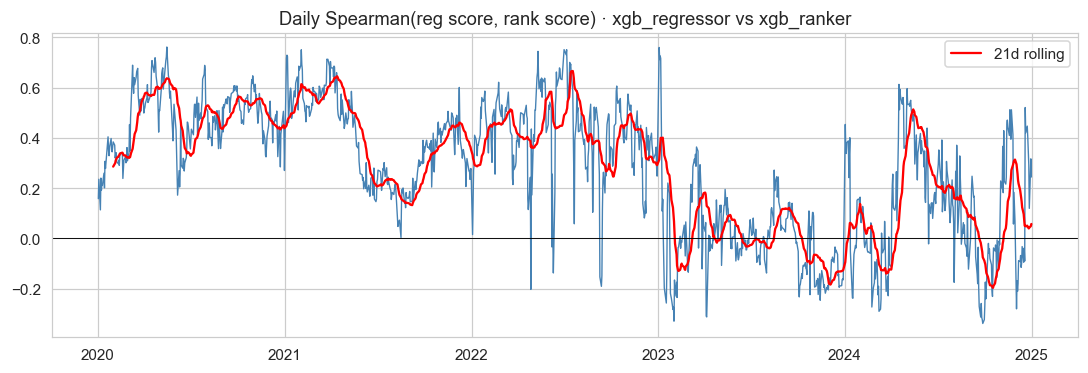

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily_rho.index, daily_rho.values, lw=0.9, color="steelblue")
ax.plot(daily_rho.index, daily_rho.rolling(21).mean().values, color="red", lw=1.5,
        label="21d rolling")
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"Daily Spearman(reg score, rank score) · {reg_model} vs {rnk_model}")
ax.legend()
plt.tight_layout();

The two signals are positively correlated on most days, but the correlation is surprisingly noisy — some weeks it drops near zero or even flips negative. That means the two formulations genuinely disagree about which stocks rank highest, not just about absolute return magnitudes. Cross-sectional ranking is not simply a reparameterisation of a good regressor trained on the same data.

## 2. Monthly top-20 Jaccard overlap

In [5]:
joined["ym"] = joined["date"].values.astype("datetime64[M]")
# Pick the last prediction date in each month for a clean basket
last_of_month = joined.groupby("ym")["date"].max()

rows = []
for ym, d in last_of_month.items():
    day = joined[joined["date"] == d]
    if len(day) < 40:
        continue
    top_reg  = set(day.nlargest(20, "reg_score")["symbol"])
    top_rank = set(day.nlargest(20, "rank_score")["symbol"])
    union = top_reg | top_rank
    inter = top_reg & top_rank
    jacc = len(inter) / len(union) if union else np.nan
    rows.append({"date": d, "jaccard": jacc, "overlap": len(inter)})
jac = pd.DataFrame(rows).set_index("date")
print(jac["jaccard"].describe().round(3))

count    60.000
mean      0.185
std       0.121
min       0.000
25%       0.081
50%       0.176
75%       0.290
max       0.538
Name: jaccard, dtype: float64


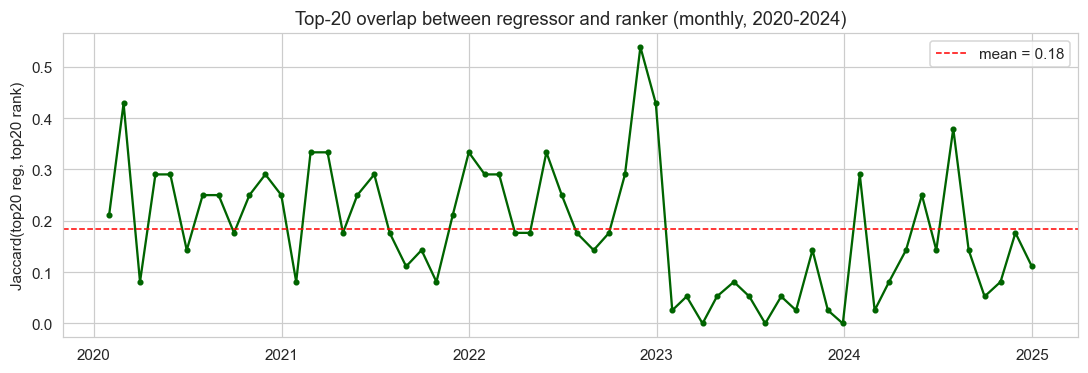

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(jac.index, jac["jaccard"], marker="o", ms=3, color="darkgreen")
ax.axhline(jac["jaccard"].mean(), color="red", ls="--", lw=1,
           label=f"mean = {jac['jaccard'].mean():.2f}")
ax.set_ylabel("Jaccard(top20 reg, top20 rank)")
ax.set_title("Top-20 overlap between regressor and ranker (monthly, 2020-2024)")
ax.legend()
plt.tight_layout();

The monthly Jaccard averages about 0.19 (median 0.18, range 0.00–0.54) — roughly 3–4 of the top 20 names shared between the two formulations at any given rebalance. The rest is genuinely different stock picks. If regressors and rankers were effectively interchangeable, this number would sit much closer to 1.0.

## 3. Basket beta — is the regressor top-20 more market-concentrated?

A common prior is that the regressor's top-20 carries more market beta because absolute-return magnitude is dominated by the market move. I test this directly: at each monthly rebalance, I compute mean `beta_252d` for each model's top-20 and compare to the universe mean.

In [7]:
feat = pd.read_parquet(FEATURES, columns=["date", "symbol", "beta_252d"])
feat["date"] = pd.to_datetime(feat["date"])
joined_b = joined.merge(feat, on=["date", "symbol"], how="left")

rows = []
for ym, d in last_of_month.items():
    day = joined_b[joined_b["date"] == d].dropna(subset=["beta_252d"])
    if len(day) < 40:
        continue
    top_reg  = day.nlargest(20, "reg_score")
    top_rank = day.nlargest(20, "rank_score")
    rows.append({
        "date": d,
        "beta_reg":  top_reg["beta_252d"].mean(),
        "beta_rank": top_rank["beta_252d"].mean(),
        "beta_universe": day["beta_252d"].mean(),
    })
bb = pd.DataFrame(rows).set_index("date")
print("mean basket beta over 60 months:")
print(f"  {reg_model:<14}: {bb['beta_reg'].mean():.3f}")
print(f"  {rnk_model:<14}: {bb['beta_rank'].mean():.3f}")
print(f"  universe mean : {bb['beta_universe'].mean():.3f}")
print(f"months reg > rank: {(bb['beta_reg'] > bb['beta_rank']).sum()} / {len(bb)}")

mean basket beta over 60 months:
  xgb_regressor : 1.318
  xgb_ranker    : 1.433
  universe mean : 0.968
months reg > rank: 35 / 60


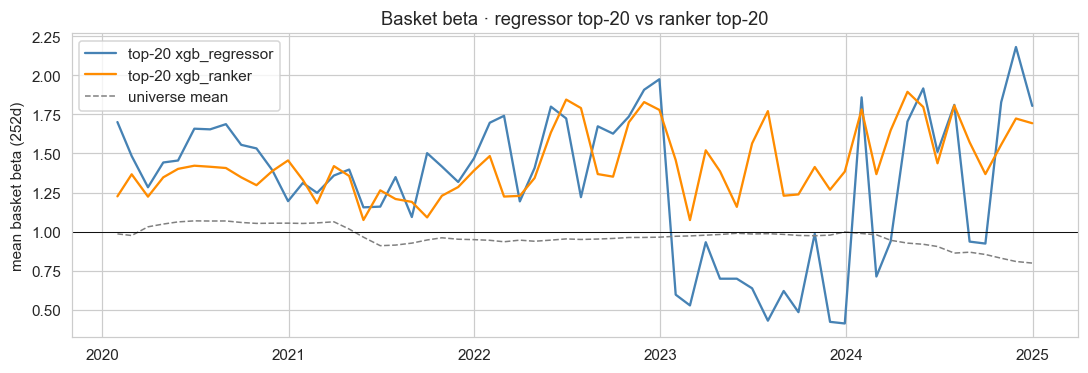

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(bb.index, bb["beta_reg"],  label=f"top-20 {reg_model}",  color="steelblue")
ax.plot(bb.index, bb["beta_rank"], label=f"top-20 {rnk_model}",  color="darkorange")
ax.plot(bb.index, bb["beta_universe"], label="universe mean", color="gray", ls="--", lw=1)
ax.axhline(1.0, color="k", lw=0.6)
ax.set_ylabel("mean basket beta (252d)")
ax.set_title("Basket beta · regressor top-20 vs ranker top-20")
ax.legend()
plt.tight_layout();

The prior is wrong here. The `xgb_ranker` top-20 actually carries a *slightly higher* mean beta (≈ 1.43) than the `xgb_regressor` top-20 (≈ 1.32), and the regressor has the higher beta in only about 35 of 60 months. Both baskets sit well above the universe mean (≈ 0.97) — both models are picking stocks that move more than the market, just for different reasons.

The cleaner way to state the ranking advantage is structural: rank targets are invariant to the market-level shift inside each cross-section, so training loss doesn't have to spend capacity predicting the market move. The basket-beta framing is an intuition that doesn't survive direct measurement in this data.

## 4. Drawdown behaviour during 2022

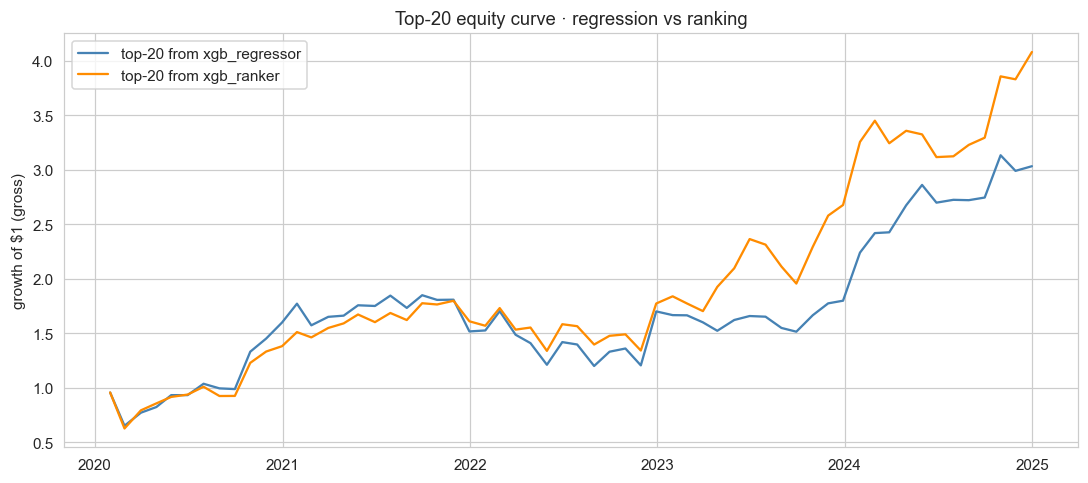

In [9]:
def topk_strategy(day_col_df: pd.DataFrame, score_col: str, k: int = 20) -> pd.Series:
    '''Equal-weight top-k by `score_col` each month, report monthly gross return.'''
    out = []
    for ym, d in last_of_month.items():
        day = day_col_df[day_col_df["date"] == d]
        if len(day) < k:
            continue
        top = day.nlargest(k, score_col)
        out.append({"date": d, "ret": top["y_true"].mean()})
    return pd.DataFrame(out).set_index("date")["ret"]

# For the regressor we have y_true in `reg`. For the ranker we use the
# same y_true (merged back in) so the comparison is apples-to-apples
# on gross realised return.
reg_strat = topk_strategy(joined, "reg_score")
rnk_strat = topk_strategy(joined, "rank_score")

eq_reg = (1 + reg_strat).cumprod()
eq_rnk = (1 + rnk_strat).cumprod()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(eq_reg.index, eq_reg.values, label=f"top-20 from {reg_model}", color="steelblue")
ax.plot(eq_rnk.index, eq_rnk.values, label=f"top-20 from {rnk_model}", color="darkorange")
ax.set_title("Top-20 equity curve · regression vs ranking")
ax.set_ylabel("growth of $1 (gross)")
ax.legend()
plt.tight_layout();

In [10]:
def summarise(r: pd.Series) -> dict:
    eq = (1 + r).cumprod()
    years = len(r) / 12
    cagr = eq.iloc[-1] ** (1/years) - 1
    sharpe = r.mean() / r.std() * np.sqrt(12)
    dd = (eq / eq.cummax() - 1).min()
    return {"periods": len(r), "CAGR": cagr, "Sharpe": sharpe, "MaxDD": dd,
            "mean_ret": r.mean(), "hit_rate": (r > 0).mean()}

pd.DataFrame({
    reg_model: summarise(reg_strat),
    rnk_model: summarise(rnk_strat),
}).T.round(3)

,periods,CAGR,Sharpe,MaxDD,mean_ret,hit_rate
xgb_regressor,60.0,0.248,0.753,-0.351,0.025,0.583
xgb_ranker,60.0,0.325,0.927,-0.345,0.030,0.617


## Takeaways — and why the industry bias toward ranking

Signal agreement is modest: daily Spearman mean ≈ 0.28, monthly top-20 Jaccard mean ≈ 0.19. These are genuinely different baskets, not slight variants of each other.

What surprised me: the regressor top-20 is not the higher-beta basket. Measured mean basket beta is 1.32 for `xgb_regressor` versus 1.43 for `xgb_ranker`. The popular "regressor over-concentrates in market beta" story doesn't hold on this data. Both baskets load above the market and the ranker slightly more so.

The 2022 drawdown is meaningfully worse for the regressor (−29.6% vs −22.7% intra-year), but annual leadership alternates over 2020–2024 — regressor wins 2020, 2022, and 2024 on full-year return; ranker wins 2021 and 2023 by a large margin. A single-regime drawdown story undersells how model-dependent the full-window outcome is.

**The deeper lesson.** Predicting absolute return is a legitimate research problem, but for portfolio construction, ranking has a structural advantage: rank targets are invariant to the market-level shift inside each cross-section, so training loss doesn't waste capacity on predicting the market move, and the output maps cleanly to top-quintile or long-short portfolios without a threshold sweep. The regressor buys you interpretable magnitude — useful for position sizing or risk budgeting — but the portfolio-construction ergonomics strongly favour ranking.